## Imbalanced

Imbalance data refers to a situation in which the classes within the dataset are not represented equally.

**Is a classification problem that affects the target variable.**


#### Loading and preparing the data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

from sklearn.utils import resample

In [13]:
titanic = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/titanic_train.csv")
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


- Check for anomalies

In [14]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Upon checking the number of null values, we are going to drop the column **Cabin** and also dropping rows where **Age** is null.

In [15]:
titanic.drop(columns="Cabin", inplace = True)
titanic.dropna(inplace=True)

In [16]:
titanic.shape

(712, 11)

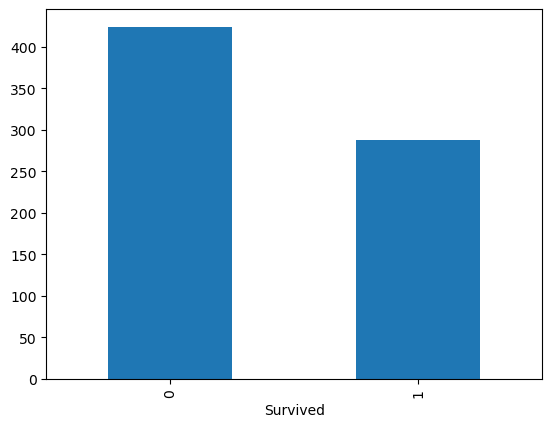

In [17]:
survived = titanic["Survived"].value_counts()
survived.plot(kind="bar")
plt.show()

- Preparing the data before modeling

In [18]:
titanic.drop(columns=["Name", "Ticket", "PassengerId"], inplace = True)

In [19]:
titanic["Sex"] = titanic["Sex"].replace({"male":0,
                                         "female":1})

C:\Users\manda\AppData\Local\Temp\ipykernel_34968\1812906043.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic["Sex"] = titanic["Sex"].replace({"male":0,


In [20]:
titanic = pd.get_dummies(titanic, columns=["Embarked"],dtype =int)

In [21]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


For baseline, we will train a Logistic Regression in imbalanced data.

In [22]:
features = titanic.drop(columns = ["Survived"])
target = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(features, target)

In [23]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
log_reg = LogisticRegression()

In [25]:
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [26]:
log_reg.score(X_test_scaled, y_test)

0.797752808988764

In [27]:
pred = log_reg.predict(X_test_scaled)
print(classification_report(y_pred = pred, y_true = y_test))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        68

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



#### Oversampling

In [28]:
train = pd.DataFrame(X_train_scaled, columns = X_train.columns)
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,-0.307897,-0.761500,-0.748971,-0.553579,-0.517541,-0.453335,-0.465189,-0.197257,0.523892
1,0.901052,-0.761500,0.145619,-0.553579,-0.517541,-0.502049,-0.465189,-0.197257,0.523892
2,-0.307897,1.313198,-0.129639,-0.553579,-0.517541,-0.406040,-0.465189,-0.197257,0.523892
3,-0.307897,-0.761500,-0.473712,-0.553579,-0.517541,-0.406040,-0.465189,-0.197257,0.523892
4,0.901052,1.313198,-0.198454,-0.553579,1.875244,-0.441354,-0.465189,-0.197257,0.523892
...,...,...,...,...,...,...,...,...,...
529,0.901052,-0.761500,0.007990,-0.553579,-0.517541,-0.499684,-0.465189,-0.197257,0.523892
530,0.901052,-0.761500,-0.611342,-0.553579,-0.517541,-0.492433,-0.465189,-0.197257,0.523892
531,-0.307897,-0.761500,0.076804,0.529246,0.678852,0.048072,2.149663,-0.197257,-1.908790
532,0.901052,1.313198,0.627321,0.529246,5.464422,-0.060313,-0.465189,-0.197257,0.523892


In [29]:
train["Survived"] = y_train.values
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
0,-0.307897,-0.761500,-0.748971,-0.553579,-0.517541,-0.453335,-0.465189,-0.197257,0.523892,1
1,0.901052,-0.761500,0.145619,-0.553579,-0.517541,-0.502049,-0.465189,-0.197257,0.523892,0
2,-0.307897,1.313198,-0.129639,-0.553579,-0.517541,-0.406040,-0.465189,-0.197257,0.523892,1
3,-0.307897,-0.761500,-0.473712,-0.553579,-0.517541,-0.406040,-0.465189,-0.197257,0.523892,0
4,0.901052,1.313198,-0.198454,-0.553579,1.875244,-0.441354,-0.465189,-0.197257,0.523892,1
...,...,...,...,...,...,...,...,...,...,...
529,0.901052,-0.761500,0.007990,-0.553579,-0.517541,-0.499684,-0.465189,-0.197257,0.523892,0
530,0.901052,-0.761500,-0.611342,-0.553579,-0.517541,-0.492433,-0.465189,-0.197257,0.523892,0
531,-0.307897,-0.761500,0.076804,0.529246,0.678852,0.048072,2.149663,-0.197257,-1.908790,0
532,0.901052,1.313198,0.627321,0.529246,5.464422,-0.060313,-0.465189,-0.197257,0.523892,0


In [30]:
survived = train[train["Survived"] == 1]
no_survived = train[train["Survived"] == 0]

In [35]:
yes_titanic_oversampled = resample(survived, 
                                    replace=True, 
                                    n_samples = len(no_survived),
                                    random_state=0)
yes_titanic_oversampled.shape

(314, 10)

In [36]:
train_over = pd.concat([yes_titanic_oversampled, no_survived])
train_over

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
399,0.901052,1.313198,-1.712375,3.777724,1.875244,-0.058185,-0.465189,-0.197257,0.523892,1
137,-1.516847,1.313198,1.934798,-0.553579,0.678852,2.251231,-0.465189,-0.197257,0.523892,1
275,-1.516847,1.313198,-0.748971,-0.553579,-0.517541,-0.084434,-0.465189,-0.197257,0.523892,1
456,-0.307897,-0.761500,-1.999332,-0.553579,1.875244,-0.103352,-0.465189,-0.197257,0.523892,1
177,-1.516847,-0.761500,1.797169,-0.553579,-0.517541,0.019615,2.149663,-0.197257,-1.908790,1
...,...,...,...,...,...,...,...,...,...,...
528,-0.307897,-0.761500,-0.473712,-0.553579,-0.517541,-0.406040,-0.465189,-0.197257,0.523892,0
529,0.901052,-0.761500,0.007990,-0.553579,-0.517541,-0.499684,-0.465189,-0.197257,0.523892,0
530,0.901052,-0.761500,-0.611342,-0.553579,-0.517541,-0.492433,-0.465189,-0.197257,0.523892,0
531,-0.307897,-0.761500,0.076804,0.529246,0.678852,0.048072,2.149663,-0.197257,-1.908790,0


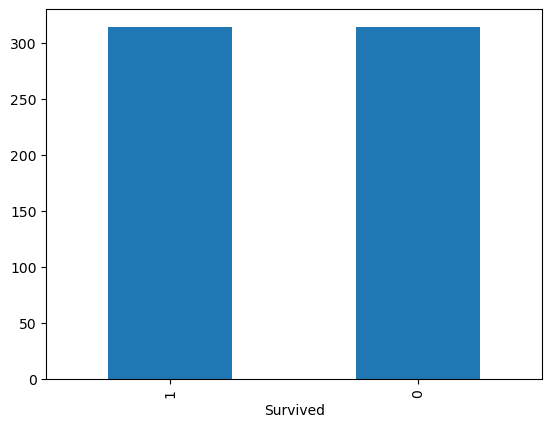

In [37]:
survived_plt = train_over["Survived"].value_counts()
survived_plt.plot(kind="bar")
plt.show()

- Now, with balanced data, we will create a new instance of Logistic Regression.

In [38]:
X_train_over = train_over.drop(columns = ["Survived"])
y_train_over = train_over["Survived"]

In [39]:
log_reg = LogisticRegression()
log_reg.fit(X_train_over, y_train_over)

LogisticRegression()

In [40]:
pred = log_reg.predict(X_test_scaled)
print(classification_report(y_pred = pred, y_true = y_test))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       110
           1       0.74      0.82      0.78        68

    accuracy                           0.82       178
   macro avg       0.81      0.82      0.81       178
weighted avg       0.83      0.82      0.82       178



C:\Users\manda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


#### Undersampling

Undersampling involves removing data points from the majority class to align its size with that of the minority class

In [43]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
0,-0.307897,-0.761500,-0.748971,-0.553579,-0.517541,-0.453335,-0.465189,-0.197257,0.523892,1
1,0.901052,-0.761500,0.145619,-0.553579,-0.517541,-0.502049,-0.465189,-0.197257,0.523892,0
2,-0.307897,1.313198,-0.129639,-0.553579,-0.517541,-0.406040,-0.465189,-0.197257,0.523892,1
3,-0.307897,-0.761500,-0.473712,-0.553579,-0.517541,-0.406040,-0.465189,-0.197257,0.523892,0
4,0.901052,1.313198,-0.198454,-0.553579,1.875244,-0.441354,-0.465189,-0.197257,0.523892,1
...,...,...,...,...,...,...,...,...,...,...
529,0.901052,-0.761500,0.007990,-0.553579,-0.517541,-0.499684,-0.465189,-0.197257,0.523892,0
530,0.901052,-0.761500,-0.611342,-0.553579,-0.517541,-0.492433,-0.465189,-0.197257,0.523892,0
531,-0.307897,-0.761500,0.076804,0.529246,0.678852,0.048072,2.149663,-0.197257,-1.908790,0
532,0.901052,1.313198,0.627321,0.529246,5.464422,-0.060313,-0.465189,-0.197257,0.523892,0


In [44]:
no_titanic_undersampled = resample(no_survived, 
                                    replace=False, 
                                    n_samples = len(survived),
                                    random_state=0)
no_titanic_undersampled

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
97,0.901052,-0.761500,-0.439305,-0.553579,-0.517541,-0.515212,2.149663,-0.197257,-1.908790,0
532,0.901052,1.313198,0.627321,0.529246,5.464422,-0.060313,-0.465189,-0.197257,0.523892,0
256,-1.516847,-0.761500,0.007990,-0.553579,-0.517541,-0.126999,2.149663,-0.197257,-1.908790,0
276,-1.516847,-0.761500,1.728354,-0.553579,-0.517541,-0.074975,-0.465189,-0.197257,0.523892,0
172,0.901052,-0.761500,0.558506,-0.553579,-0.517541,-0.518602,-0.465189,-0.197257,0.523892,0
...,...,...,...,...,...,...,...,...,...,...
426,0.901052,-0.761500,-1.574746,3.777724,0.678852,0.098834,-0.465189,-0.197257,0.523892,0
146,0.901052,-0.761500,-0.748971,-0.553579,-0.517541,-0.502601,-0.465189,-0.197257,0.523892,0
405,0.901052,-0.761500,-0.955415,3.777724,0.678852,0.098834,-0.465189,-0.197257,0.523892,0
281,0.901052,1.313198,-1.299487,3.777724,1.875244,-0.060313,-0.465189,-0.197257,0.523892,0


In [45]:
train_under = pd.concat([no_titanic_undersampled, survived])
train_under

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
97,0.901052,-0.761500,-0.439305,-0.553579,-0.517541,-0.515212,2.149663,-0.197257,-1.908790,0
532,0.901052,1.313198,0.627321,0.529246,5.464422,-0.060313,-0.465189,-0.197257,0.523892,0
256,-1.516847,-0.761500,0.007990,-0.553579,-0.517541,-0.126999,2.149663,-0.197257,-1.908790,0
276,-1.516847,-0.761500,1.728354,-0.553579,-0.517541,-0.074975,-0.465189,-0.197257,0.523892,0
172,0.901052,-0.761500,0.558506,-0.553579,-0.517541,-0.518602,-0.465189,-0.197257,0.523892,0
...,...,...,...,...,...,...,...,...,...,...
519,0.901052,-0.761500,0.971394,-0.553579,-0.517541,-0.502049,-0.465189,-0.197257,0.523892,1
520,-1.516847,-0.761500,1.246652,0.529246,-0.517541,0.331762,-0.465189,-0.197257,0.523892,1
521,-1.516847,1.313198,0.420877,-0.553579,-0.517541,1.913938,2.149663,-0.197257,-1.908790,1
524,0.901052,-0.761500,-0.336083,-0.553579,-0.517541,-0.651974,-0.465189,-0.197257,0.523892,1


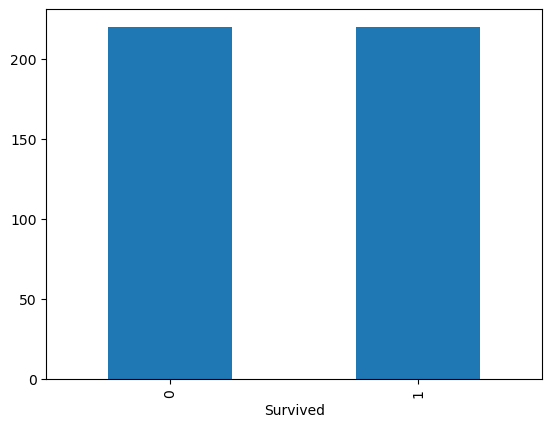

In [46]:
survived_plt = train_under["Survived"].value_counts()
survived_plt.plot(kind="bar")
plt.show()

Now, we have the same amount of observations for both survived and not_survived. Let's see how it can impact our model 

- Separating our features from our target

In [47]:
X_train_under = train_under.drop(columns = ["Survived"])
y_train_under = train_under["Survived"]

- Model training

In [48]:
log_reg = LogisticRegression()
log_reg.fit(X_train_under, y_train_under)

LogisticRegression()

- Evaluate our model

In [49]:
pred = log_reg.predict(X_test_scaled)
print(classification_report(y_pred = pred, y_true = y_test))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85       110
           1       0.73      0.81      0.77        68

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.81       178
weighted avg       0.82      0.81      0.82       178



C:\Users\manda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


#### SMOTE

SMOTE utilizes KNN approach to generate synthetic samples for the minority class.

SMOTE comes from a different package - **imblearn**

In [50]:
from imblearn.over_sampling import SMOTE

Now, we need to create a SMOTE object in order to balance our data

- **sampling_strategy** - corresponds to the ratio of the number of samples in the minority class over the number of samples in the majority class.

In [51]:
sm = SMOTE(random_state = 1,sampling_strategy=1.0)

In [52]:
X_train_sm,y_train_sm = sm.fit_resample(X_train_scaled,y_train)

- Now lets train our model, to see if get any improvements.

In [53]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=1000)

- Evaluate our model

In [54]:
pred = log_reg.predict(X_test_scaled)
print(classification_report(y_pred = pred, y_true = y_test))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85       110
           1       0.75      0.82      0.78        68

    accuracy                           0.83       178
   macro avg       0.82      0.83      0.82       178
weighted avg       0.83      0.83      0.83       178

